# NK Cell Subclustering — HD vs MM (Foster et al.)
## Addresses Reviewer Comment 16 (Fig 5F)

**Goal:** Subcluster NK cells from HD and MM, identify AP-1-driven subpopulations,
determine whether AP-1 depletion in MM is driven by loss of a specific NK subcluster
or reflects a broad change across all clusters.

**Run cells in order.**

In [1]:
# ============================================================
# CELL 0: INSTALL  (restarts the runtime on first run)
# ============================================================
import importlib.util, subprocess, sys, os

if importlib.util.find_spec("scanpy") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "scanpy", "anndata", "scikit-learn", "leidenalg",
                    "pandas==2.2.2"], check=True)   # keep Colab's pinned pandas
    print("Installed — restarting. Run CELL 1 next.")
    os.kill(os.getpid(), 9)
else:
    print("scanpy present — go to CELL 1.")

scanpy present — go to CELL 1.


In [2]:
# ============================================================
# CELL 1: SETUP
# ============================================================
!pip -q install scanpy anndata scikit-learn leidenalg

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.sparse as sp
from scipy import stats
from itertools import combinations
import statsmodels.stats.multitest as multitest
from scipy.stats import mannwhitneyu
import shutil, os, glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'

from google.colab import drive
print('Mounting Google Drive...')
drive.mount('/content/drive', force_remount=True)
print('Done!')

Mounting Google Drive...
Mounted at /content/drive
Done!


In [3]:
# ============================================================
# CELL 2: LOAD DATA + DISEASE CATEGORIZATION
# ============================================================
file_path     = '/content/drive/My Drive/scRNAseq data/panImmune.h5ad'
metadata_path = '/content/drive/My Drive/scRNAseq data/metadata-donor.csv'

print('Loading data...')
adata = sc.read_h5ad(file_path)
print(f'Loaded: {adata.shape}')

# Disease categorization
metadata   = pd.read_csv(metadata_path)
cohort_map = {'Non': 'HD', 'MM': 'MM', 'SMM': 'SMM', 'MGUS': 'MGUS'}
metadata['disease_category'] = metadata['cohort'].map(cohort_map).fillna('Unknown')
disease_dict = dict(zip(metadata['donor_id'], metadata['disease_category']))

def categorize_disease(sample_id):
    if sample_id in disease_dict:
        return disease_dict[sample_id]
    base_id = sample_id
    for suffix in ['_pos','_neg','_BMA','_BLD','-T','-P',
                   '_T1','_T2','_T3','_1','_2','_3','_A','_B','_C']:
        base_id = base_id.replace(suffix, '')
        if base_id in disease_dict:
            return disease_dict[base_id]
    return 'Unknown'

adata.obs['disease_category'] = adata.obs['sample_id'].apply(categorize_disease)
print('\nDisease distribution:')
print(adata.obs['disease_category'].value_counts())

Loading data...
Loaded: (763657, 34849)

Disease distribution:
disease_category
HD         286370
MM         242578
SMM        181469
MGUS        37767
Unknown     15473
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 3: SUBSET NK CELLS — HD AND MM ONLY
# ============================================================
CELL_TYPE     = 'NK cell'
disease_order = ['HD', 'MM']
colors_disease = {'HD': '#4393c3', 'MM': '#d6604d'}

cells_hdmm = adata[
    (adata.obs['lineage'] == CELL_TYPE) &
    (adata.obs['disease_category'].isin(['HD', 'MM']))
].copy()

print(f'NK cells (HD + MM): {cells_hdmm.n_obs:,}')
for disease in disease_order:
    dc    = cells_hdmm[cells_hdmm.obs['disease_category'] == disease]
    n_pat = dc.obs['sample_id'].nunique()
    print(f'  {disease}: {dc.n_obs:,} cells | {n_pat} patients')

# Save raw before any processing
print('\nNormalizing and saving raw...')
sc.pp.normalize_total(cells_hdmm, target_sum=1e4)
sc.pp.log1p(cells_hdmm)
cells_hdmm.raw = cells_hdmm.copy()   # save log-normalized as raw
print('Done — raw saved for dotplot expression values')

NK cells (HD + MM): 44,840
  HD: 29,966 cells | 87 patients
  MM: 14,874 cells | 59 patients

Normalizing and saving raw...
Done — raw saved for dotplot expression values


In [5]:
# ============================================================
# CELL 4: SUBCLUSTERING
# ============================================================
print('Selecting highly variable genes...')
sc.pp.highly_variable_genes(cells_hdmm, n_top_genes=2000)
print(f'  HVGs: {cells_hdmm.var.highly_variable.sum()}')

print('Scaling...')
sc.pp.scale(cells_hdmm, max_value=10)

print('Running PCA...')
sc.tl.pca(cells_hdmm, n_comps=30)

print('Computing neighbors...')
sc.pp.neighbors(cells_hdmm, n_neighbors=15, n_pcs=20)

print('Running UMAP...')
sc.tl.umap(cells_hdmm)

print('Clustering (leiden resolution=0.5)...')
sc.tl.leiden(cells_hdmm, resolution=0.5, key_added='leiden_nk')

clusters = sorted(cells_hdmm.obs['leiden_nk'].unique())
print(f'\nTotal clusters: {len(clusters)}')
print('\nCluster sizes:')
print(cells_hdmm.obs['leiden_nk'].value_counts().sort_index())

print('\nCluster composition (HD vs MM):')
comp = cells_hdmm.obs.groupby(
    ['leiden_nk', 'disease_category']
).size().unstack(fill_value=0)
comp['Total']  = comp.sum(axis=1)
comp['HD_pct'] = (comp['HD'] / comp['Total'] * 100).round(1)
comp['MM_pct'] = (comp['MM'] / comp['Total'] * 100).round(1)
print(comp)

Selecting highly variable genes...
  HVGs: 2000
Scaling...
Running PCA...
Computing neighbors...
Running UMAP...
Clustering (leiden resolution=0.5)...

Total clusters: 14

Cluster sizes:
leiden_nk
0     8771
1     7030
2     5488
3     4746
4     3587
5     3320
6     2598
7     1986
8     1926
9     1624
10    1369
11    1204
12     766
13     425
Name: count, dtype: int64

Cluster composition (HD vs MM):
disease_category    HD    MM  Total  HD_pct  MM_pct
leiden_nk                                          
0                 8756    15   8771    99.8     0.2
1                 3875  3155   7030    55.1    44.9
2                 5477    11   5488    99.8     0.2
3                 1422  3324   4746    30.0    70.0
4                 3584     3   3587    99.9     0.1
5                   13  3307   3320     0.4    99.6
6                    0  2598   2598     0.0   100.0
7                    2  1984   1986     0.1    99.9
8                 1919     7   1926    99.6     0.4
9                 

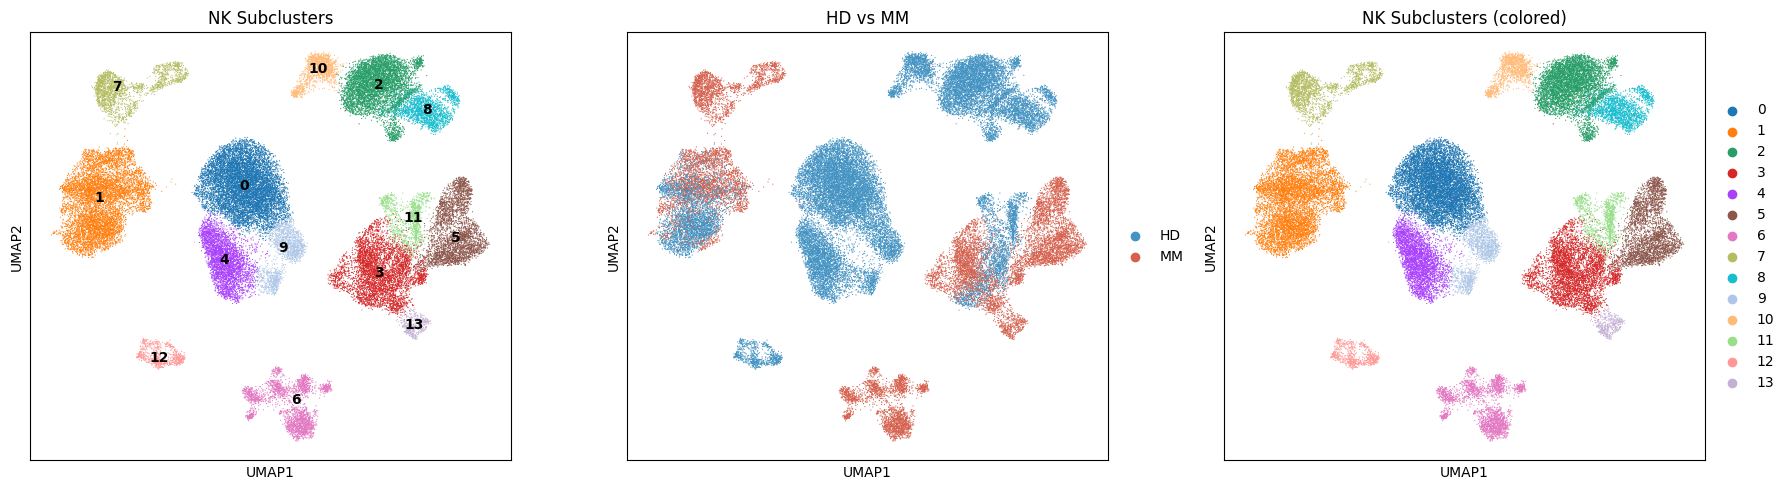

Saved: NK_UMAP_subclusters_HDvsMM (PDF, TIFF, PNG)


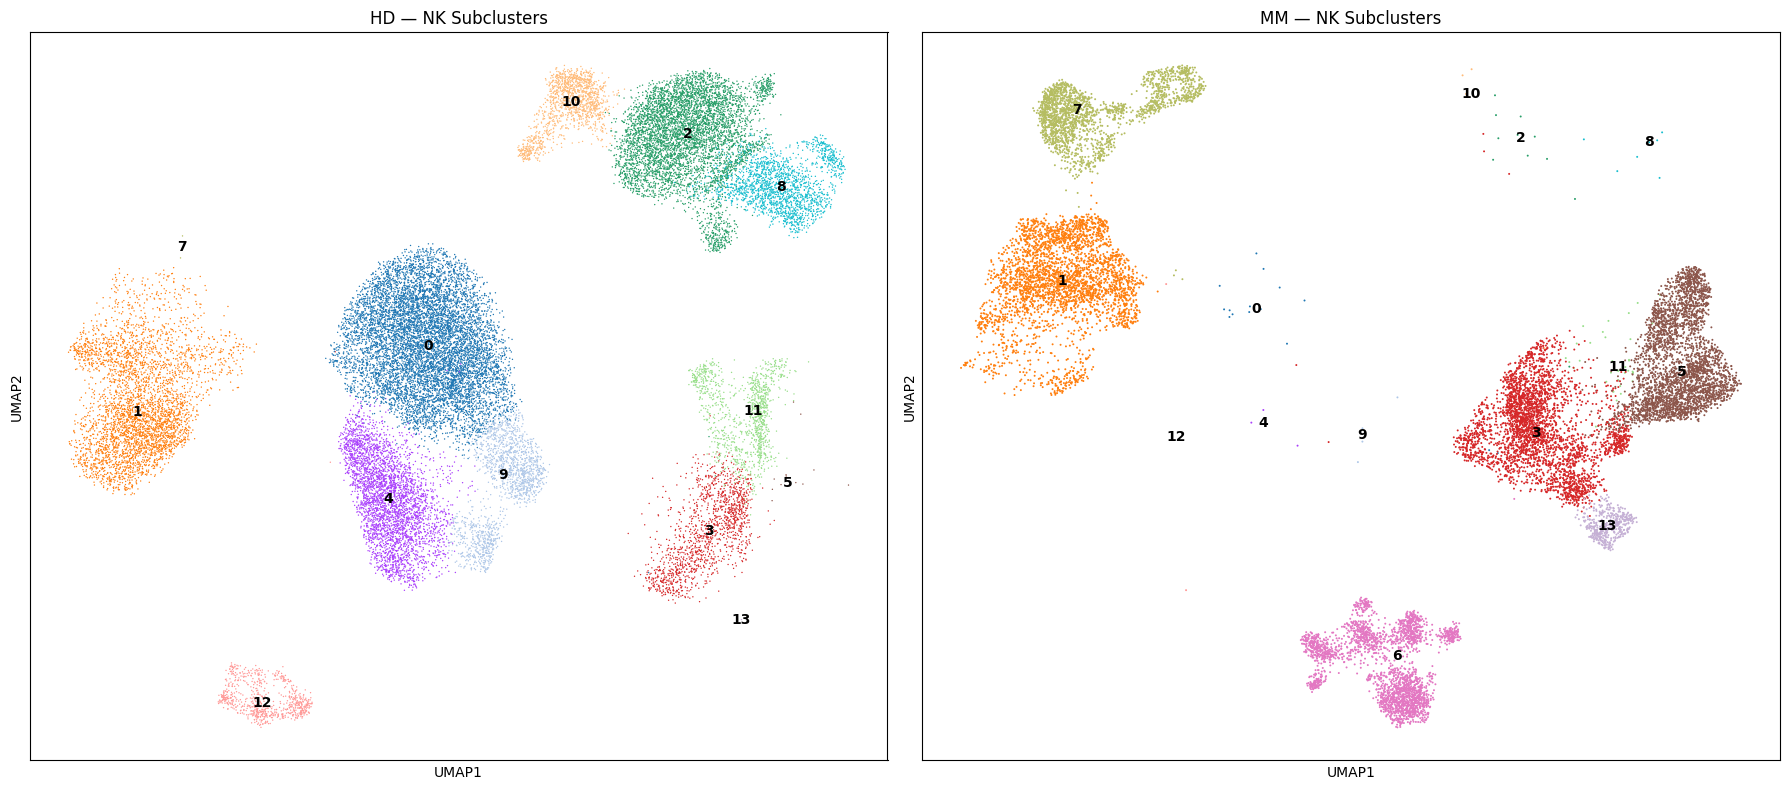

Saved: NK_UMAP_split_HDvsMM (PDF, TIFF, PNG)


In [6]:
# ============================================================
# CELL 5: UMAP PLOTS
# ============================================================

# Figure 1: 3-panel UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(cells_hdmm, color='leiden_nk',
           title='NK Subclusters',
           legend_loc='on data',
           ax=axes[0], show=False)

sc.pl.umap(cells_hdmm, color='disease_category',
           title='HD vs MM',
           palette={'HD': '#4393c3', 'MM': '#d6604d'},
           ax=axes[1], show=False)

sc.pl.umap(cells_hdmm, color='leiden_nk',
           title='NK Subclusters (colored)',
           ax=axes[2], show=False)

plt.tight_layout()
for ext in ['pdf', 'png', 'tiff']:
    plt.savefig(f'NK_UMAP_subclusters_HDvsMM.{ext}',
                dpi=300, bbox_inches='tight', format=ext)
plt.show()
print('Saved: NK_UMAP_subclusters_HDvsMM (PDF, TIFF, PNG)')

# Figure 2: Split UMAP HD vs MM
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, disease in zip(axes, ['HD', 'MM']):
    dc = cells_hdmm[cells_hdmm.obs['disease_category'] == disease]
    sc.pl.umap(dc,
               color='leiden_nk',
               title=f'{disease} — NK Subclusters',
               legend_loc='on data',
               ax=ax, show=False)

plt.tight_layout()
for ext in ['pdf', 'png', 'tiff']:
    plt.savefig(f'NK_UMAP_split_HDvsMM.{ext}',
                dpi=300, bbox_inches='tight', format=ext)
plt.show()
print('Saved: NK_UMAP_split_HDvsMM (PDF, TIFF, PNG)')

In [7]:
# ============================================================
# CELL 6: AP-1 EXPRESSION BY SUBCLUSTER
# Uses raw (log-normalized, unscaled) expression
# ============================================================

print(f'Raw exists: {cells_hdmm.raw is not None}')
print(f'X min/max (scaled): {cells_hdmm.X.min():.3f} / {cells_hdmm.X.max():.3f}')

ap1_genes = ['JUN', 'JUNB', 'JUND', 'FOS', 'FOSB', 'FOSL1', 'FOSL2']
avail_ap1 = [g for g in ap1_genes if g in cells_hdmm.var_names]
print(f'\nAP-1 genes available: {avail_ap1}')

def get_expr(adata_subset, gene):
    """Get log-normalized unscaled expression using raw if available."""
    if adata_subset.raw is not None:
        raw_var_names = list(adata_subset.raw.var_names)
        if gene in raw_var_names:
            idx  = raw_var_names.index(gene)
            expr = adata_subset.raw.X[:, idx]
            if sp.issparse(expr):
                expr = expr.toarray().flatten()
            else:
                expr = np.array(expr).flatten()
            return expr
    # Fallback: use scaled X
    expr = adata_subset[:, gene].X
    if sp.issparse(expr):
        expr = expr.toarray().flatten()
    else:
        expr = np.array(expr).flatten()
    return expr

# Calculate per cluster per disease
records = []
for cluster in clusters:
    for disease in disease_order:
        mask = ((cells_hdmm.obs['leiden_nk'] == cluster) &
                (cells_hdmm.obs['disease_category'] == disease))
        dc = cells_hdmm[mask]
        if dc.n_obs < 5:
            continue
        for gene in avail_ap1:
            expr = get_expr(dc, gene)
            records.append({
                'cluster':   str(cluster),
                'disease':   disease,
                'gene':      gene,
                'mean_expr': np.mean(expr),
                'pct_expr':  (expr > 0).sum() / len(expr) * 100,
                'n_cells':   dc.n_obs
            })

ap1_df = pd.DataFrame(records)
print(f'\nExpression range: {ap1_df["mean_expr"].min():.3f} — {ap1_df["mean_expr"].max():.3f}')
print(f'\nSample:')
print(ap1_df.head(10))

Raw exists: True
X min/max (scaled): -10.000 / 10.000

AP-1 genes available: ['JUN', 'JUNB', 'JUND', 'FOS', 'FOSB', 'FOSL1', 'FOSL2']

Expression range: 0.000 — 2.936

Sample:
  cluster disease   gene  mean_expr   pct_expr  n_cells
0       0      HD    JUN   1.789561  71.665144     8756
1       0      HD   JUNB   2.043839  83.702604     8756
2       0      HD   JUND   0.368295  18.981270     8756
3       0      HD    FOS   1.928305  76.747373     8756
4       0      HD   FOSB   0.453000  22.430333     8756
5       0      HD  FOSL1   0.004645   0.228415     8756
6       0      HD  FOSL2   0.362297  19.026953     8756
7       0      MM    JUN   2.133935  66.666667       15
8       0      MM   JUNB   0.628886  20.000000       15
9       0      MM   JUND   0.845884  26.666667       15


Expression range for plotting: 0 — 2.936


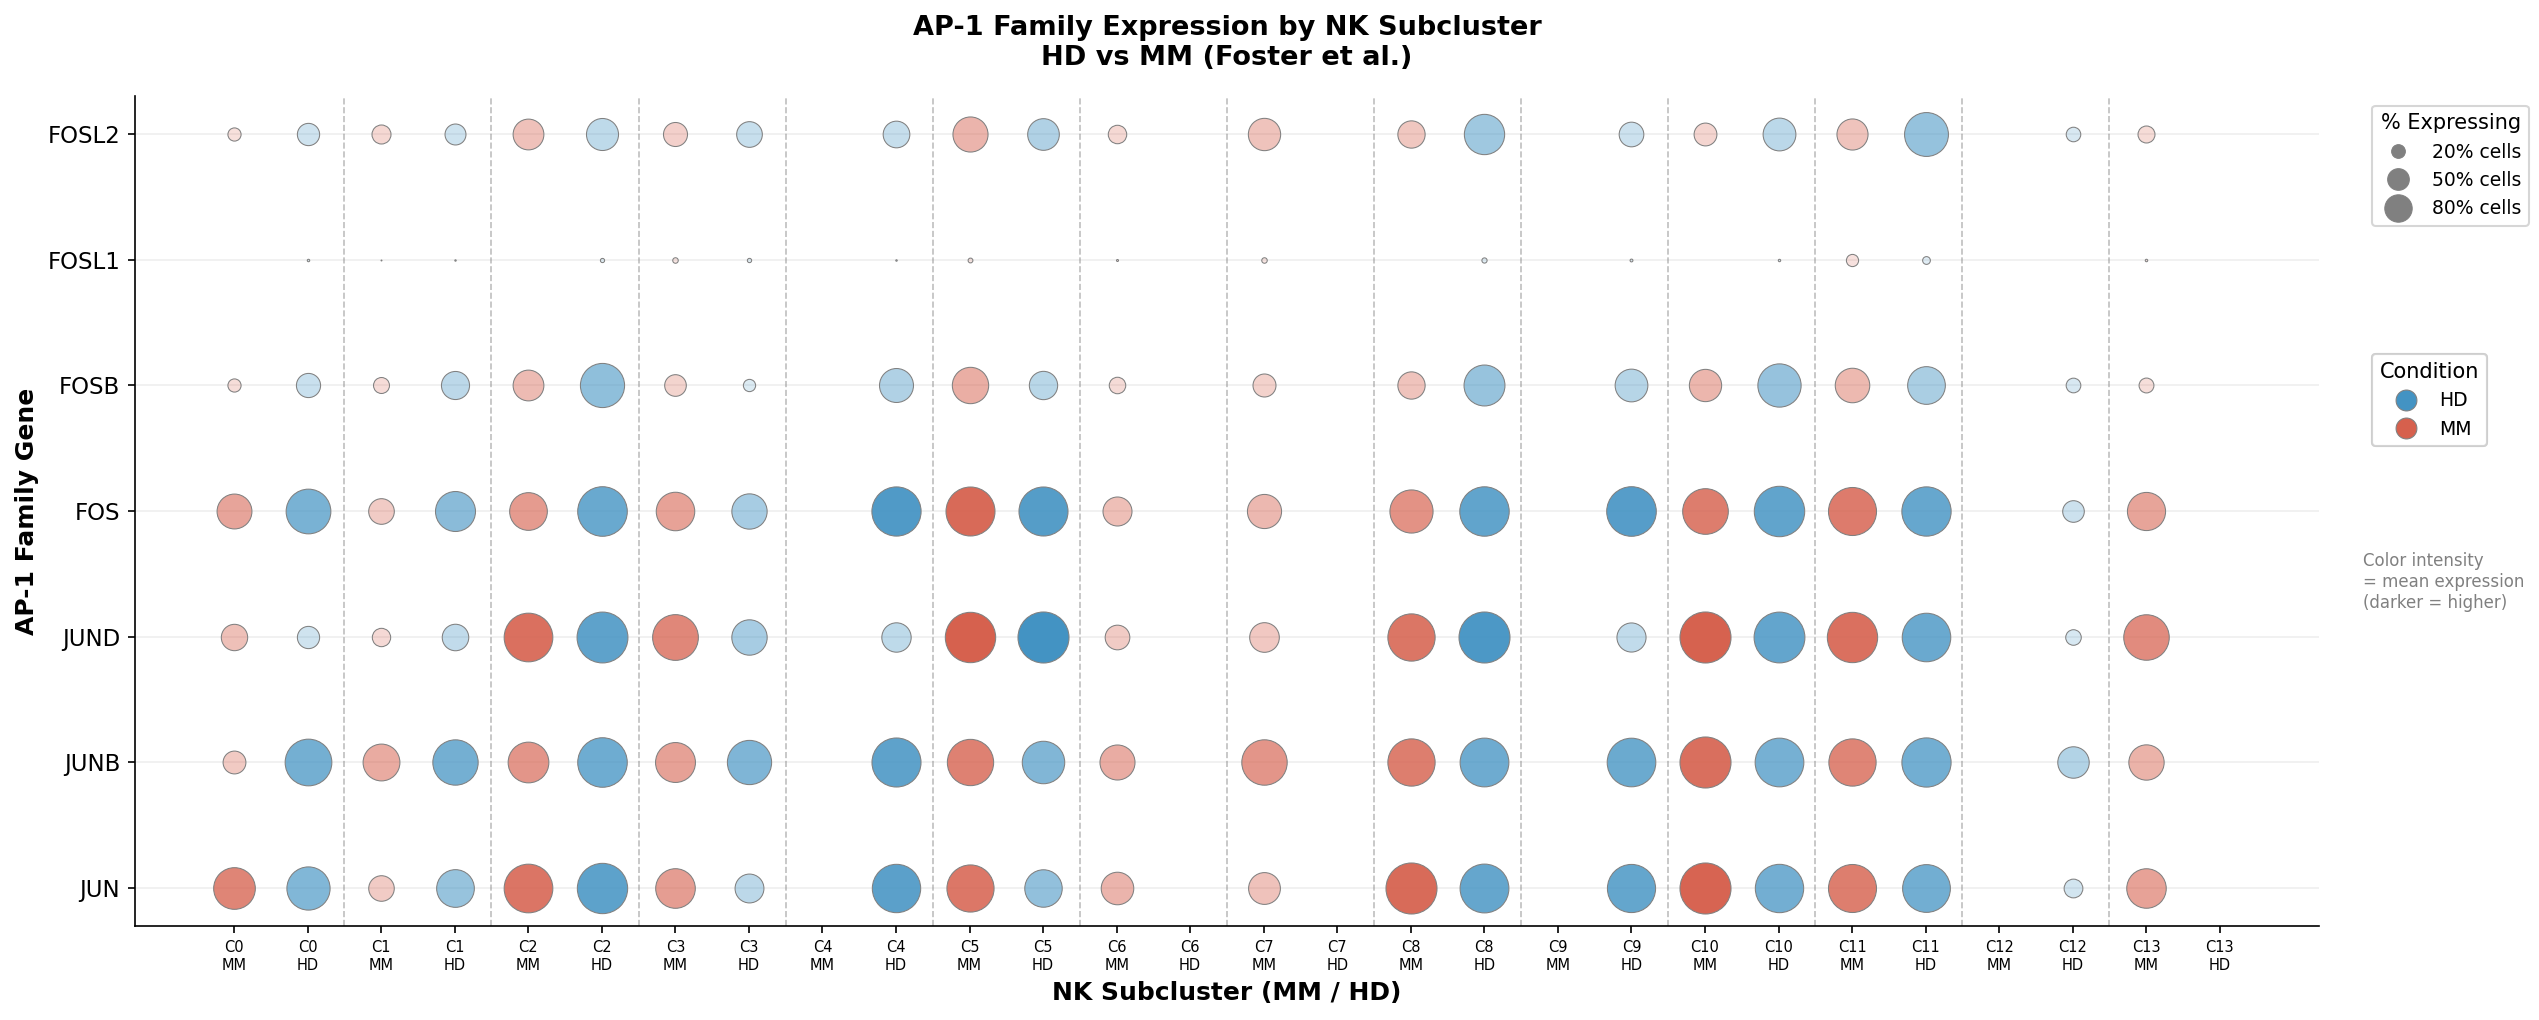

Saved: AP1_NK_subcluster_HDvsMM (PDF, PNG, TIFF)


In [8]:
# ============================================================
# CELL 7: AP-1 DOTPLOT BY SUBCLUSTER — HD vs MM
# HD = blue, MM = red, intensity = expression level
# Clusters sorted numerically
# ============================================================

# Fix: convert both columns to str before concatenating
cells_hdmm.obs['cluster_disease'] = (
    cells_hdmm.obs['leiden_nk'].astype(str) + '_' +
    cells_hdmm.obs['disease_category'].astype(str)
)

# Sort clusters numerically
clusters     = sorted(cells_hdmm.obs['leiden_nk'].unique(),
                      key=lambda x: int(x))
clusters_str = [str(c) for c in clusters]

labels_ordered = []
for cluster in clusters_str:
    for disease in ['MM', 'HD']:
        labels_ordered.append(f'{cluster}_{disease}')

# Build matrices
mean_mat = pd.DataFrame(index=avail_ap1,
                         columns=labels_ordered, dtype=float)
pct_mat  = pd.DataFrame(index=avail_ap1,
                         columns=labels_ordered, dtype=float)

for label in labels_ordered:
    parts   = label.rsplit('_', 1)
    cluster = parts[0]
    disease = parts[1]
    for gene in avail_ap1:
        row = ap1_df[
            (ap1_df['cluster'] == cluster) &
            (ap1_df['disease'] == disease) &
            (ap1_df['gene']    == gene)
        ]
        if len(row) > 0:
            mean_mat.loc[gene, label] = row['mean_expr'].values[0]
            pct_mat.loc[gene, label]  = row['pct_expr'].values[0]
        else:
            mean_mat.loc[gene, label] = 0
            pct_mat.loc[gene, label]  = 0

# Clip negatives to 0
mean_mat_plot = mean_mat.clip(lower=0)
max_expr      = float(mean_mat_plot.max().max())
print(f'Expression range for plotting: 0 — {max_expr:.3f}')

# Draw dotplot — dpi=150 so screen preview matches saved output
fig, ax = plt.subplots(
    figsize=(len(labels_ordered) * 0.5 + 3,
             len(avail_ap1) * 0.7 + 2),
    dpi=150
)

for i, gene in enumerate(avail_ap1):
    for j, label in enumerate(labels_ordered):
        disease   = label.rsplit('_', 1)[1]
        mean_expr = float(mean_mat_plot.loc[gene, label])
        pct_expr  = float(pct_mat.loc[gene, label])
        size      = max(pct_expr * 6, 0)

        # Alpha driven by expression intensity
        alpha = 0.15 + 0.85 * (mean_expr / max_expr) if max_expr > 0 else 0.15

        # Fill color by disease, intensity by expression
        if disease == 'HD':
            color = (0.263, 0.576, 0.765, alpha)  # blue
        else:
            color = (0.839, 0.376, 0.302, alpha)  # red

        ax.scatter(j, i, s=size, c=[color],
                   edgecolors='grey',
                   linewidth=0.5, zorder=2)

# Cluster separator lines
for k in range(1, len(clusters_str)):
    ax.axvline(k * 2 - 0.5, color='grey',
               linewidth=0.8, linestyle='--', alpha=0.5)

# X-axis labels
x_labels = []
for label in labels_ordered:
    parts   = label.rsplit('_', 1)
    cluster = parts[0]
    disease = parts[1]
    x_labels.append(f'C{cluster}\n{disease}')

ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(x_labels, fontsize=7)
ax.set_yticks(range(len(avail_ap1)))
ax.set_yticklabels(avail_ap1, fontsize=11)
ax.set_xlabel('NK Subcluster (MM / HD)', fontsize=12, fontweight='bold')
ax.set_ylabel('AP-1 Family Gene',        fontsize=12, fontweight='bold')
ax.set_title(
    'AP-1 Family Expression by NK Subcluster\nHD vs MM (Foster et al.)',
    fontsize=13, fontweight='bold', pad=15
)
ax.grid(alpha=0.2, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend — dot size
pct_levels  = [20, 50, 80]
size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='grey',
           markeredgecolor='grey',
           markeredgewidth=0.5,
           markersize=np.sqrt(p * 6) * 0.6,
           label=f'{p}% cells')
    for p in pct_levels
]

# Legend — disease color
disease_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#4393c3',
           markeredgecolor='grey',
           markeredgewidth=0.5,
           markersize=10, label='HD'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#d6604d',
           markeredgecolor='grey',
           markeredgewidth=0.5,
           markersize=10, label='MM')
]

l1 = ax.legend(handles=size_legend,
               loc='upper left', bbox_to_anchor=(1.02, 1.0),
               title='% Expressing', frameon=True,
               fontsize=9, title_fontsize=10)
ax.add_artist(l1)

l2 = ax.legend(handles=disease_legend,
               loc='upper left', bbox_to_anchor=(1.02, 0.70),
               title='Condition', frameon=True,
               fontsize=9, title_fontsize=10)
ax.add_artist(l2)

# Note about color intensity
ax.text(1.02, 0.45,
        'Color intensity\n= mean expression\n(darker = higher)',
        transform=ax.transAxes,
        fontsize=8, va='top', ha='left', color='grey')

plt.tight_layout()

# Save fig object explicitly before plt.show() clears it
fig.savefig('AP1_NK_subcluster_HDvsMM.pdf',
            dpi=300, bbox_inches='tight', format='pdf')
fig.savefig('AP1_NK_subcluster_HDvsMM.tiff',
            dpi=300, bbox_inches='tight', format='tiff')
fig.savefig('AP1_NK_subcluster_HDvsMM.png',
            dpi=300, bbox_inches='tight', format='png')

plt.show()
print('Saved: AP1_NK_subcluster_HDvsMM (PDF, PNG, TIFF)')

Expression range for plotting: 0 — 2.936
Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_NK_subcluster_HDvsMM.pdf (55.6 KB)
Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_NK_subcluster_HDvsMM.tiff (42955.0 KB)
Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_NK_subcluster_HDvsMM.png (590.3 KB)


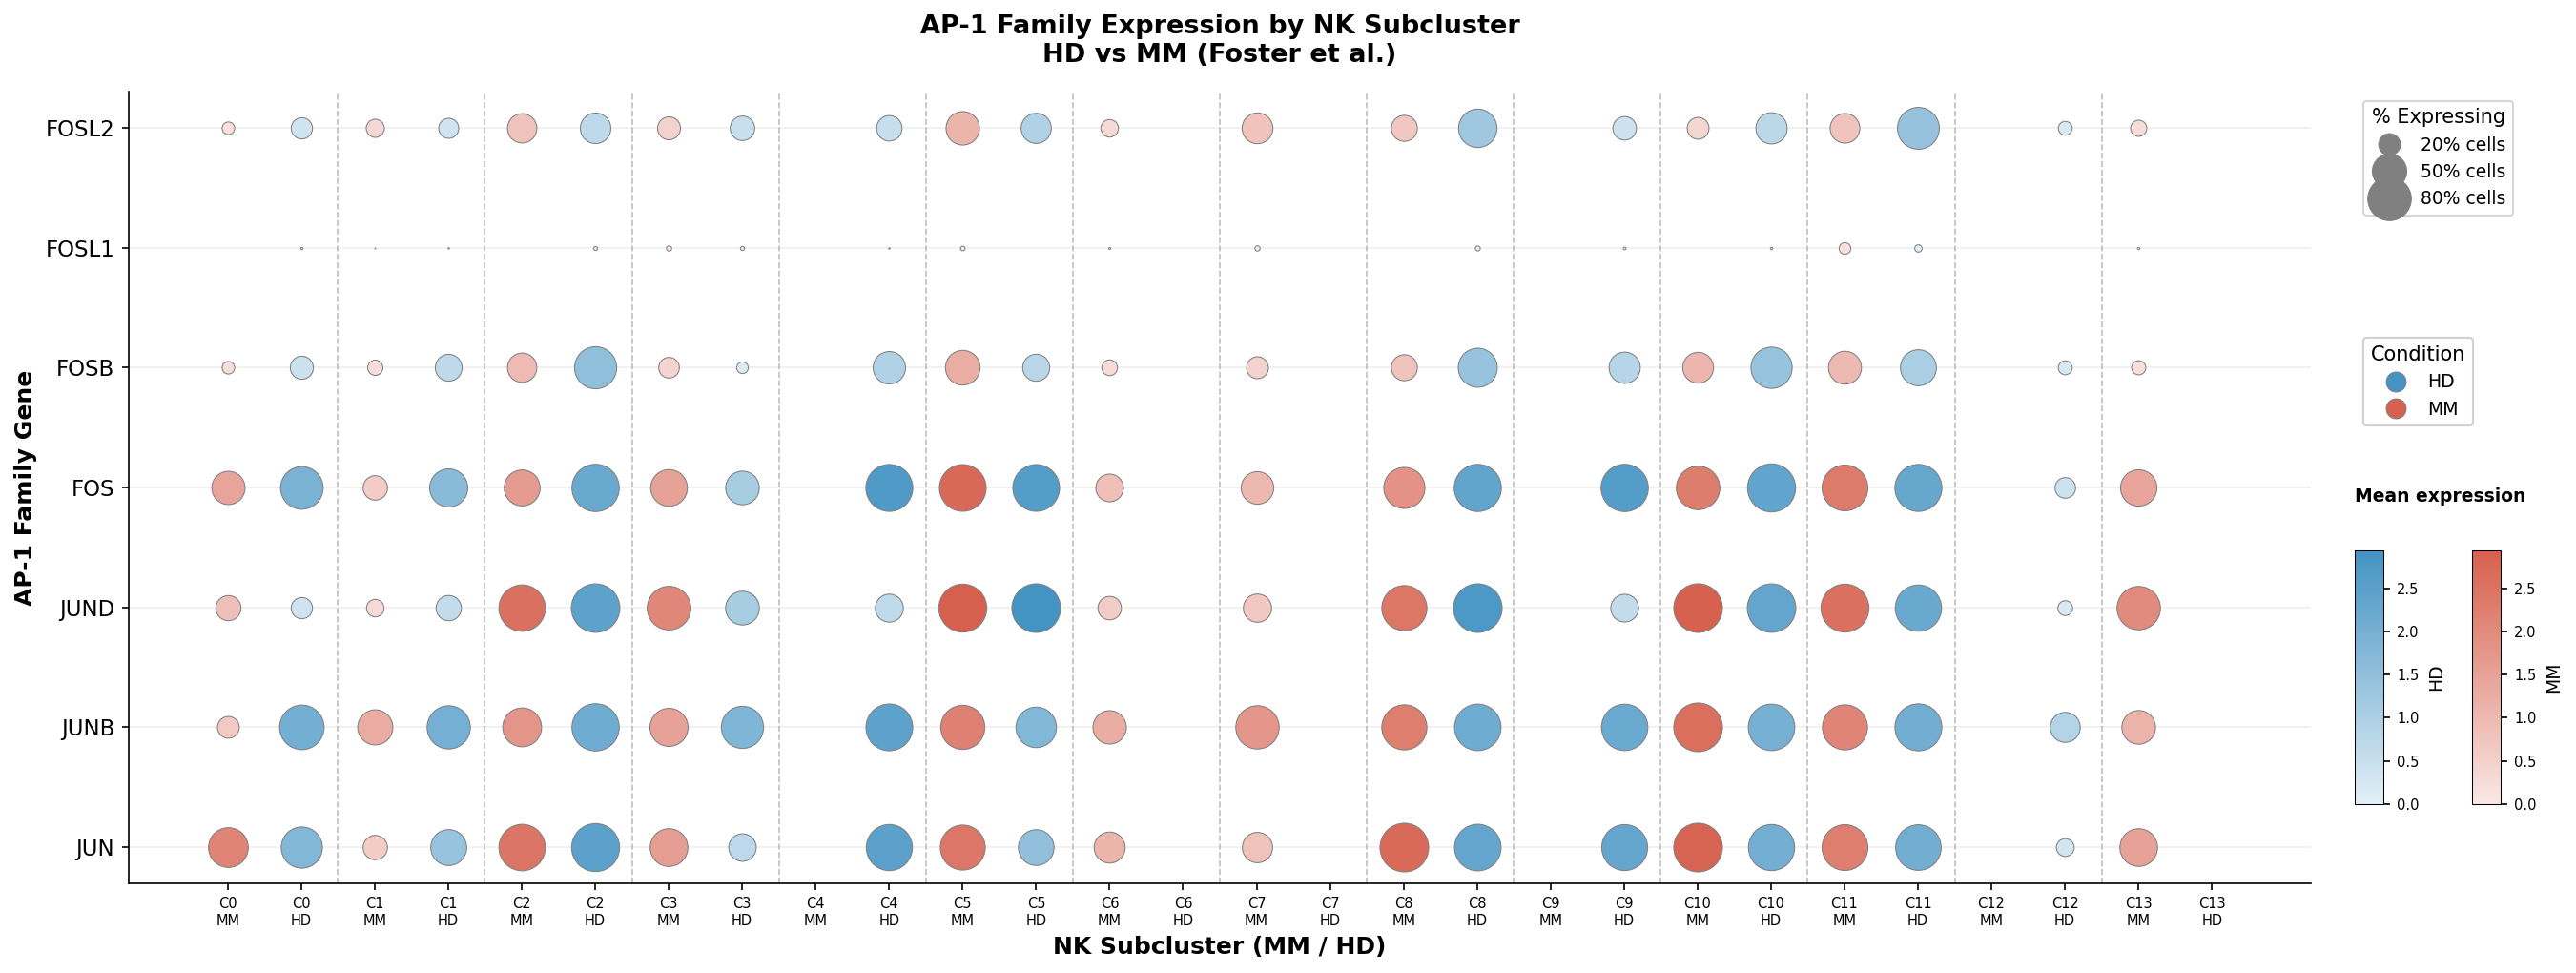

In [9]:
# ============================================================
# CELL 7: AP-1 DOTPLOT BY NK SUBCLUSTER — HD vs MM
#   dot size      = % of cells expressing
#   dot colour    = condition (HD blue / MM red)
#   dot intensity = mean expression, with a colour bar per condition
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

mpl.rcParams['pdf.fonttype'] = 42          # TrueType -> editable text in the PDF
mpl.rcParams['ps.fonttype']  = 42

SAVE_DIR  = '/content/drive/My Drive/scRNAseq data/figures'
SAVE_NAME = 'AP1_NK_subcluster_HDvsMM'

# ---- 1. cluster x disease labels --------------------------------------------
cells_hdmm.obs['cluster_disease'] = (
    cells_hdmm.obs['leiden_nk'].astype(str) + '_' +
    cells_hdmm.obs['disease_category'].astype(str)
)

clusters_str = sorted(cells_hdmm.obs['leiden_nk'].astype(str).unique(),
                      key=lambda x: int(x))

labels_ordered = []
for cluster in clusters_str:
    for disease in ['MM', 'HD']:
        labels_ordered.append(f'{cluster}_{disease}')

# ---- 2. matrices -------------------------------------------------------------
# pivot_table instead of a nested loop: same result, far faster, and it cannot
# silently miss a gene x label combination
ap1_df = ap1_df.copy()
ap1_df['label'] = (ap1_df['cluster'].astype(str) + '_' +
                   ap1_df['disease'].astype(str))

mean_mat = (ap1_df.pivot_table(index='gene', columns='label', values='mean_expr')
                  .reindex(index=avail_ap1, columns=labels_ordered)
                  .fillna(0.0))
pct_mat  = (ap1_df.pivot_table(index='gene', columns='label', values='pct_expr')
                  .reindex(index=avail_ap1, columns=labels_ordered)
                  .fillna(0.0))

mean_mat_plot = mean_mat.clip(lower=0)      # clip negative scaled values to 0
max_expr      = float(mean_mat_plot.max().max())
print(f'Expression range for plotting: 0 — {max_expr:.3f}')

# ---- 3. colour ramps ---------------------------------------------------------
def alpha_ramp(rgb, a_min=0.15, a_max=1.0, n=256):
    """Solid colormap reproducing 'this colour at alpha a, over white'."""
    a = np.linspace(a_min, a_max, n)[:, None]
    return LinearSegmentedColormap.from_list('', a * np.array(rgb) + (1 - a))

HD_RGB, MM_RGB   = (0.263, 0.576, 0.765), (0.839, 0.376, 0.302)
hd_cmap, mm_cmap = alpha_ramp(HD_RGB), alpha_ramp(MM_RGB)
norm = mpl.colors.Normalize(vmin=0, vmax=max_expr)

# ---- 4. figure ---------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(len(labels_ordered) * 0.5 + 4,
             len(avail_ap1) * 0.7 + 2),
    dpi=150,
)

for i, gene in enumerate(avail_ap1):
    for j, label in enumerate(labels_ordered):
        disease   = label.rsplit('_', 1)[1]
        mean_expr = float(mean_mat_plot.loc[gene, label])
        pct_expr  = float(pct_mat.loc[gene, label])
        size      = max(pct_expr * 6, 0)

        # colormap lookup rather than alpha: identical on white, but stable
        # where dots overlap and exactly matched by the colour bars below
        cmap  = hd_cmap if disease == 'HD' else mm_cmap
        ax.scatter(j, i, s=size, color=cmap(norm(mean_expr)),
                   edgecolors='grey', linewidth=0.5, zorder=2)

# cluster separators
for k in range(1, len(clusters_str)):
    ax.axvline(k * 2 - 0.5, color='grey',
               linewidth=0.8, linestyle='--', alpha=0.5)

x_labels = [f"C{l.rsplit('_', 1)[0]}\n{l.rsplit('_', 1)[1]}" for l in labels_ordered]
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(x_labels, fontsize=7)
ax.set_yticks(range(len(avail_ap1)))
ax.set_yticklabels(avail_ap1, fontsize=11)
ax.set_xlabel('NK Subcluster (MM / HD)', fontsize=12, fontweight='bold')
ax.set_ylabel('AP-1 Family Gene',        fontsize=12, fontweight='bold')
ax.set_title('AP-1 Family Expression by NK Subcluster\nHD vs MM (Foster et al.)',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(alpha=0.2, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- 5. legends --------------------------------------------------------------
# markersize is a DIAMETER in points, scatter s is an AREA in points^2,
# so sqrt(s) is what makes the keys match the plotted dots
pct_levels  = [20, 50, 80]
size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='grey', markeredgecolor='grey',
           markeredgewidth=0.5, markersize=np.sqrt(p * 6),
           label=f'{p}% cells')
    for p in pct_levels
]
disease_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4393c3',
           markeredgecolor='grey', markeredgewidth=0.5, markersize=10, label='HD'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d6604d',
           markeredgecolor='grey', markeredgewidth=0.5, markersize=10, label='MM'),
]

l1 = ax.legend(handles=size_legend, loc='upper left', bbox_to_anchor=(1.02, 1.0),
               title='% Expressing', frameon=True, fontsize=9, title_fontsize=10)
ax.add_artist(l1)

l2 = ax.legend(handles=disease_legend, loc='upper left', bbox_to_anchor=(1.02, 0.70),
               title='Condition', frameon=True, fontsize=9, title_fontsize=10)
ax.add_artist(l2)

# ---- 6. expression colour bars ----------------------------------------------
# draw() first: get_window_extent() is meaningless until the figure is laid out,
# and sizing the bars in inches keeps them constant as cluster count changes
fig.canvas.draw()
ax_w_in = ax.get_window_extent().width / fig.dpi
bar_w   = 0.18 / ax_w_in
bar_gap = 0.75 / ax_w_in

ax.text(1.02, 0.50, 'Mean expression', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top', ha='left')

for k, (cm, lab) in enumerate([(hd_cmap, 'HD'), (mm_cmap, 'MM')]):
    cax = ax.inset_axes([1.02 + k * bar_gap, 0.10, bar_w, 0.32])
    cb  = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cm), cax=cax)
    cb.set_label(lab, fontsize=9, labelpad=4)
    cb.ax.tick_params(labelsize=7)
    cb.outline.set_linewidth(0.5)

plt.tight_layout()

# ---- 7. save -----------------------------------------------------------------
os.makedirs(SAVE_DIR, exist_ok=True)
for ext in ['pdf', 'tiff', 'png']:
    fp = os.path.join(SAVE_DIR, f'{SAVE_NAME}.{ext}')
    fig.savefig(fp, dpi=300, bbox_inches='tight', format=ext)
    print(f'Saved: {fp} ({os.path.getsize(fp) / 1024:.1f} KB)')

plt.show()

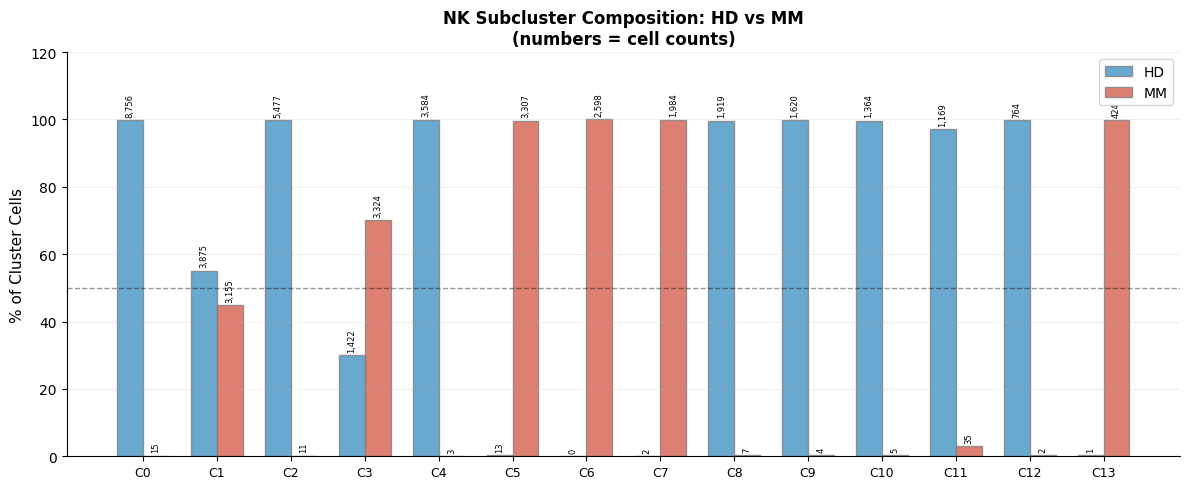

Saved: NK_cluster_composition_HDvsMM (PDF, PNG, TIFF)

Full composition table:
disease_category    HD    MM  Total  HD_pct  MM_pct
leiden_nk                                          
0                 8756    15   8771    99.8     0.2
1                 3875  3155   7030    55.1    44.9
2                 5477    11   5488    99.8     0.2
3                 1422  3324   4746    30.0    70.0
4                 3584     3   3587    99.9     0.1
5                   13  3307   3320     0.4    99.6
6                    0  2598   2598     0.0   100.0
7                    2  1984   1986     0.1    99.9
8                 1919     7   1926    99.6     0.4
9                 1620     4   1624    99.8     0.2
10                1364     5   1369    99.6     0.4
11                1169    35   1204    97.1     2.9
12                 764     2    766    99.7     0.3
13                   1   424    425     0.2    99.8


In [10]:
# ============================================================
# CELL 8: CLUSTER COMPOSITION BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

comp_pct = comp[['HD', 'MM']].div(comp['Total'], axis=0) * 100

x = np.arange(len(comp_pct))
w = 0.35

ax.bar(x - w/2, comp_pct['HD'], w,
       label='HD', color='#4393c3', alpha=0.8, edgecolor='grey')
ax.bar(x + w/2, comp_pct['MM'], w,
       label='MM', color='#d6604d', alpha=0.8, edgecolor='grey')

# Cell count labels
for i, cluster in enumerate(comp_pct.index):
    n_hd = comp.loc[cluster, 'HD']
    n_mm = comp.loc[cluster, 'MM']
    ax.text(i - w/2, comp_pct.loc[cluster, 'HD'] + 1,
            f'{n_hd:,}', ha='center', va='bottom',
            fontsize=6, rotation=90)
    ax.text(i + w/2, comp_pct.loc[cluster, 'MM'] + 1,
            f'{n_mm:,}', ha='center', va='bottom',
            fontsize=6, rotation=90)

ax.axhline(50, color='black', linewidth=1,
           linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in comp_pct.index],
                    fontsize=9)
ax.set_ylabel('% of Cluster Cells', fontsize=11)
ax.set_title('NK Subcluster Composition: HD vs MM\n(numbers = cell counts)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 120)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
for ext in ['pdf', 'png', 'tiff']:
    plt.savefig(f'NK_cluster_composition_HDvsMM.{ext}',
                dpi=300, bbox_inches='tight', format=ext)
plt.show()
print('Saved: NK_cluster_composition_HDvsMM (PDF, PNG, TIFF)')
print('\nFull composition table:')
print(comp.to_string())

Core AP-1 genes: ['JUN', 'JUNB', 'FOS', 'FOSB']


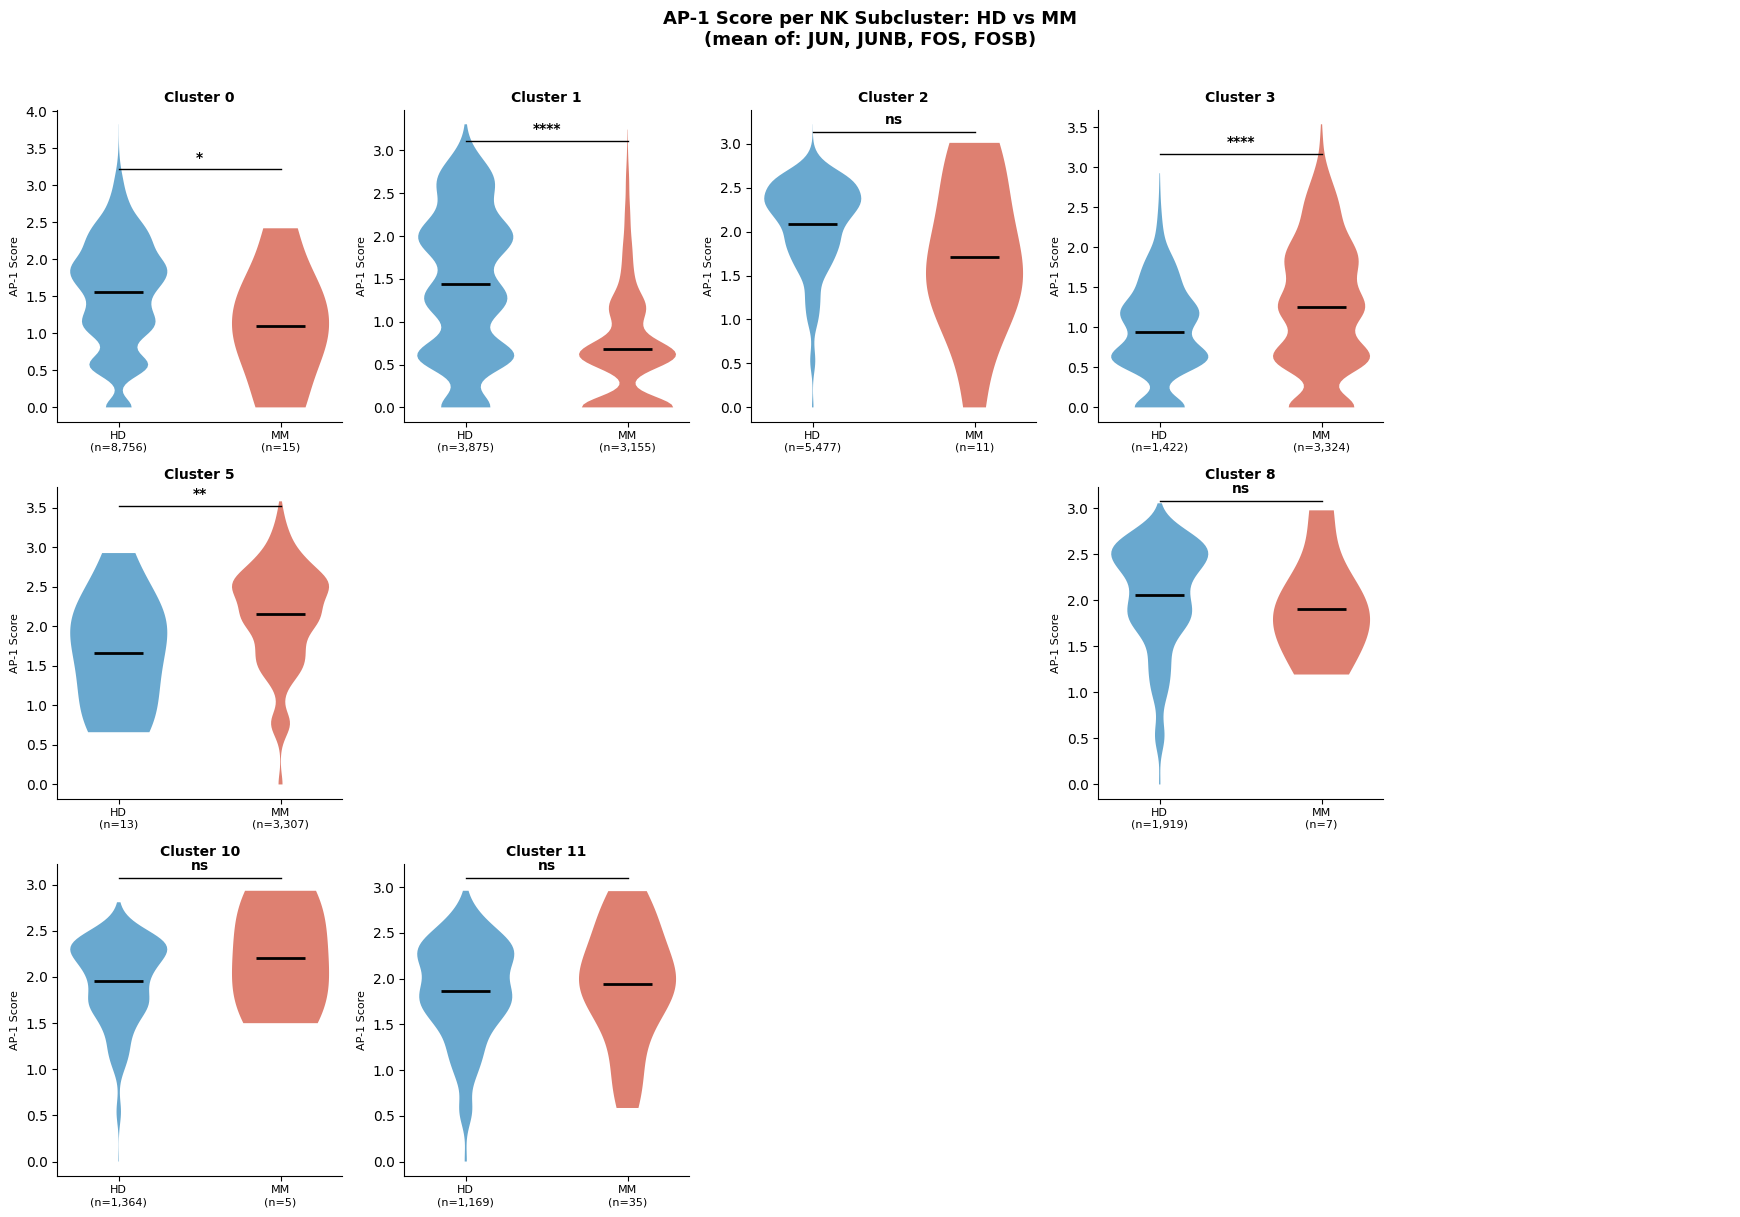

Saved: AP1_score_per_NK_cluster (PDF, PNG, TIFF)

AP-1 score HD vs MM per cluster (BH-corrected):
cluster  n_HD  n_MM  mean_HD  mean_MM  median_HD  median_MM       p_value         p_adj  sig
      0  8756    15 1.553676 1.104381   1.646143   0.909164  2.500765e-02  5.001530e-02   ns
      1  3875  3155 1.440350 0.680559   1.389864   0.612245 1.721883e-291 1.377506e-290 ****
      2  5477    11 2.089151 1.710909   2.205124   1.609852  1.106298e-01  1.770076e-01   ns
      3  1422  3324 0.936632 1.256391   0.927134   1.235210  2.410173e-35  9.640691e-35 ****
      5    13  3307 1.660685 2.150645   1.869219   2.245792  8.712546e-03  2.323346e-02    *
      8  1919     7 2.058379 1.904663   2.183875   1.873294  2.799025e-01  3.732033e-01   ns
     10  1364     5 1.956289 2.206082   2.044142   2.169501  3.631078e-01  4.149804e-01   ns
     11  1169    35 1.865555 1.940503   1.908234   2.006572  4.213035e-01  4.213035e-01   ns

Saved: AP1_cluster_stats_HDvsMM.csv


In [11]:
# ============================================================
# CELL 9: AP-1 SCORE PER CLUSTER — HD vs MM VIOLIN
# ============================================================
ap1_core   = ['JUN', 'JUNB', 'FOS', 'FOSB']
avail_core = [g for g in ap1_core if g in cells_hdmm.var_names]
print(f'Core AP-1 genes: {avail_core}')

# Calculate AP-1 score per cell using raw
ap1_expr_list = []
for gene in avail_core:
    expr = get_expr(cells_hdmm, gene)
    ap1_expr_list.append(expr)

ap1_matrix = np.vstack(ap1_expr_list).T
cells_hdmm.obs['ap1_score'] = ap1_matrix.mean(axis=1)

# Violin per cluster
n_clusters = len(clusters)
n_cols     = min(5, n_clusters)
n_rows     = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3.5, n_rows * 4))
axes_flat = axes.flatten() if n_rows > 1 else list(axes)

stat_results = []

for idx, cluster in enumerate(clusters):
    ax = axes_flat[idx]

    hd_scores = cells_hdmm[
        (cells_hdmm.obs['leiden_nk'] == cluster) &
        (cells_hdmm.obs['disease_category'] == 'HD')
    ].obs['ap1_score'].values

    mm_scores = cells_hdmm[
        (cells_hdmm.obs['leiden_nk'] == cluster) &
        (cells_hdmm.obs['disease_category'] == 'MM')
    ].obs['ap1_score'].values

    if len(hd_scores) < 5 or len(mm_scores) < 5:
        ax.axis('off')
        continue

    parts = ax.violinplot([hd_scores, mm_scores],
                           positions=[0, 1],
                           showmeans=True,
                           showextrema=False,
                           widths=0.6)
    parts['bodies'][0].set_facecolor('#4393c3')
    parts['bodies'][1].set_facecolor('#d6604d')
    for body in parts['bodies']:
        body.set_alpha(0.8)
    parts['cmeans'].set_color('black')
    parts['cmeans'].set_linewidth(2)

    _, p = mannwhitneyu(hd_scores, mm_scores,
                        alternative='two-sided')
    stat_results.append({
        'cluster':   str(cluster),
        'n_HD':      len(hd_scores),
        'n_MM':      len(mm_scores),
        'mean_HD':   np.mean(hd_scores),
        'mean_MM':   np.mean(mm_scores),
        'median_HD': np.median(hd_scores),
        'median_MM': np.median(mm_scores),
        'p_value':   p
    })

    sig = '****' if p < 0.0001 else \
          '***'  if p < 0.001  else \
          '**'   if p < 0.01   else \
          '*'    if p < 0.05   else 'ns'

    y_max = max(np.percentile(hd_scores, 99),
                np.percentile(mm_scores, 99))
    ax.plot([0, 1], [y_max * 1.05, y_max * 1.05],
            'k-', linewidth=1)
    ax.text(0.5, y_max * 1.08, sig,
            ha='center', fontsize=10, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'HD\n(n={len(hd_scores):,})',
         f'MM\n(n={len(mm_scores):,})'],
        fontsize=8
    )
    ax.set_title(f'Cluster {cluster}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('AP-1 Score', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for idx in range(len(clusters), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle(
    f'AP-1 Score per NK Subcluster: HD vs MM\n'
    f'(mean of: {", ".join(avail_core)})',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()

for ext in ['pdf', 'png', 'tiff']:
    plt.savefig(f'AP1_score_per_NK_cluster.{ext}',
                dpi=300, bbox_inches='tight', format=ext)
plt.show()
print('Saved: AP1_score_per_NK_cluster (PDF, PNG, TIFF)')

# BH correction
stat_df = pd.DataFrame(stat_results)
_, stat_df['p_adj'], _, _ = multitest.multipletests(
    stat_df['p_value'], method='fdr_bh'
)
stat_df['sig'] = stat_df['p_adj'].apply(
    lambda p: '****' if p < 0.0001 else
              '***'  if p < 0.001  else
              '**'   if p < 0.01   else
              '*'    if p < 0.05   else 'ns'
)

print('\nAP-1 score HD vs MM per cluster (BH-corrected):')
print(stat_df.to_string(index=False))
stat_df.to_csv('AP1_cluster_stats_HDvsMM.csv', index=False)
print('\nSaved: AP1_cluster_stats_HDvsMM.csv')

In [12]:
# ============================================================
# CELL 10: SAVE ALL TO GOOGLE DRIVE
# ============================================================
output_folder = '/content/drive/My Drive/NK_AP1_Exhaustion_RevisionAnalysis'
os.makedirs(output_folder, exist_ok=True)

all_files = glob.glob('*.png') + glob.glob('*.pdf') + \
            glob.glob('*.tiff') + glob.glob('*.csv')

print(f'Saving {len(all_files)} files to Drive...')
for f in all_files:
    try:
        shutil.copy(f, os.path.join(output_folder, f))
        print(f'  Saved: {f}')
    except Exception as e:
        print(f'  Error: {f} — {e}')

print(f'\nAll saved to: {output_folder}')

Saving 16 files to Drive...
  Saved: NK_UMAP_subclusters_HDvsMM.png
  Saved: AP1_score_per_NK_cluster.png
  Saved: NK_UMAP_split_HDvsMM.png
  Saved: AP1_NK_subcluster_HDvsMM.png
  Saved: NK_cluster_composition_HDvsMM.png
  Saved: NK_UMAP_split_HDvsMM.pdf
  Saved: NK_cluster_composition_HDvsMM.pdf
  Saved: AP1_score_per_NK_cluster.pdf
  Saved: AP1_NK_subcluster_HDvsMM.pdf
  Saved: NK_UMAP_subclusters_HDvsMM.pdf
  Saved: NK_cluster_composition_HDvsMM.tiff
  Saved: AP1_score_per_NK_cluster.tiff
  Saved: NK_UMAP_split_HDvsMM.tiff
  Saved: AP1_NK_subcluster_HDvsMM.tiff
  Saved: NK_UMAP_subclusters_HDvsMM.tiff
  Saved: AP1_cluster_stats_HDvsMM.csv

All saved to: /content/drive/My Drive/NK_AP1_Exhaustion_RevisionAnalysis
